# Mansfield-RS — a quantitative teardown
### Weekly basket · Stage-2 entries · random-entry control · HAC inference · survivorship-bias discussion

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Timing_adds_nothing: Confirmed](https://img.shields.io/badge/Timing_adds_nothing-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Same seven beats, every claim now carrying its standard error.  We test whether Weinstein Stage-2 entry signals (price > rising 30-week SMA AND Mansfield RS > 0) predict 13-week forward excess returns vs SPY, compared against a random-entry control on the same stocks.

> **Not investment advice.** Real data: Yahoo weekly bars (resampled from daily), as-of 2026-06-14, 15 large-cap US equities, 25 years. Reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias:** basket is a current-S&P-500 proxy; results are upper bounds.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mansfield_rs import data, strategy as st

TICKERS = data.DEFAULT_TICKERS
STOCKS = [t for t in TICKERS if t != "SPY"]
HOLD_WEEKS = 13

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-06-14).
R = dict(
    n_s2=811, n_rnd=813,
    s2_mean=29.4, s2_win=48.1, s2_t=0.72, s2_skew=0.83,
    rnd_mean=118.1, rnd_win=49.3, rnd_t=2.75,
    delta=-88.7,
    in_s2_mean=5.7, in_s2_t=1.61, in_s2_n=7423,
    out_s2_mean=9.2, out_s2_t=3.04, out_s2_n=11534,
    hold4_s2=-6, hold4_rnd=39,
    hold8_s2=-31, hold8_rnd=87,
    hold13_s2=29, hold13_rnd=118,
    hold26_s2=101, hold26_rnd=201,
    n_tickers=15, n_years=25,
    aapl_t=3.62, amzn_t=2.54, pfe_t=-1.50, wmt_t=-2.02,
    cost0_t=0.72, cost1_t=0.69, cost5_t=0.60,
    entries_per_year=2.2,
)

def _pool(tapes, cost=0.0, seed=None):
    bm = tapes["SPY"]
    frames = []
    for tk in STOCKS:
        stock = tapes[tk]
        entries = st.stage2_entries(stock, bm, sma_n=30)
        if entries.empty:
            continue
        if seed is not None:
            entries = st.random_entries(stock, n_entries=len(entries), seed=seed)
        led = st.run_forward_returns(stock, bm, entries, hold_weeks=HOLD_WEEKS, cost_bps=cost)
        frames.append(led)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def _load_tapes():
    return {t: data.fetch_weekly(t, fetch=False, cache_dir=data.DEFAULT_CACHE) for t in TICKERS}

print("real weekly cache present:", HAVE_REAL)


real weekly cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Stage-2 entry 13w excess **+29.4 bps/trade**, HAC *t* = **+0.72**; underperforms random control by **-89 bps/trade**. |
| **Tradability** | `MIRAGE` | Gross not significant; cost sweep (0–10 bps) leaves t-stat below 1 throughout; no break-even cost exists above zero. |
| **Timing adds nothing** | `CONFIRMED` | Stage-2 entries underperform random at every hold period; in-Stage-2 holding **5.7 bps/week** vs out **9.2 bps/week** (in worse). |

> The filter selects momentum stocks correctly but enters them as late confirmations; the transition signal captures lagging, not leading, information.

## 1 · The claim, steelmanned

Let $r^{excess}_{t,t+h}$ be the 13-week forward excess return of stock $i$ vs SPY. The Stage-2 recipe asserts:

- **H₁ (signal):** $\mathbb{E}[r^{excess}_{t,t+h} \mid \text{Stage2}_{t}^{new}] > 0$
  where Stage2$^{new}$ is a transition into Stage 2 (not-Stage-2 at *t−1*, Stage-2 at *t*).  In words: entering at the Stage-2 transition earns positive excess return.
- **H₂ (beats random):** That expectation exceeds the same statistic for random entry weeks on the same stock.
- **H₃ (in-stage predictive):** $\mathbb{E}[r^{excess}_{t,t+1} \mid \text{Stage2}_t] > 0$,
  i.e. being in Stage 2 predicts the next week's outperformance.

**Mansfield RS formula:**

$$\text{MRS}_t = \frac{\text{stock}_t / \text{SMA}_{30}(\text{stock})_t}{\text{benchmark}_t / \text{SMA}_{30}(\text{benchmark})_t} - 1$$

Stage-2 requires: (1) $\text{stock}_t > \text{SMA}_{30}(\text{stock})_t$, (2) $\text{SMA}_{30}$ slope over last 4 weeks $> 0$, (3) $\text{MRS}_t > 0$.

We reject H₁, H₂, and H₃ on the real tape.

## 2 · So what? — what rides on each answer

A confirmed Stage-2 signal would be a high-conviction position-sizing rule for medium-term investors: concentrate in Stage-2 leaders and expect 100-200 bps of excess return over the following quarter.  The failure here is not that momentum doesn't exist — it does (Jegadeesh & Titman 1993) — but that Weinstein's specific filter enters too late.  The Stage-2 label is a lagging confirmation of what the market already knows.

## 3 · How we'd know — the protocol

- **Entry.** Stage-2 transition signal at close of week *t*; enter at *t+1*'s open.
- **Metric.** 13-week forward excess return = stock gross return − SPY gross return over the same window (entry open to exit close of week *t+1+13*).
- **Control.** Same number of random entries drawn from the post-warmup period on the *same stock*; same hold period; same cost assumption.
- **Inference.** Newey-West HAC *t* on pooled per-trade excess returns.
- **Positive control.** A synthetic weekly tape with tunable AR(1) RS momentum; the engine must recover an edge when RS momentum is planted.
- **Hold-period sweep.** 4, 8, 13, 26 weeks.
- **Survivorship warning.** The basket is current-S&P-500 survivors; results are upper bounds.

Basket: SPY (benchmark) + 15 large-cap US equities. ~25 years of weekly data. Stage-2 warmup: 30 weeks.

## 4 · The teardown

### 4a · Per-stock Stage-2 HAC t-stat — only 2 of 15 are significant, both survivor-biased compounders

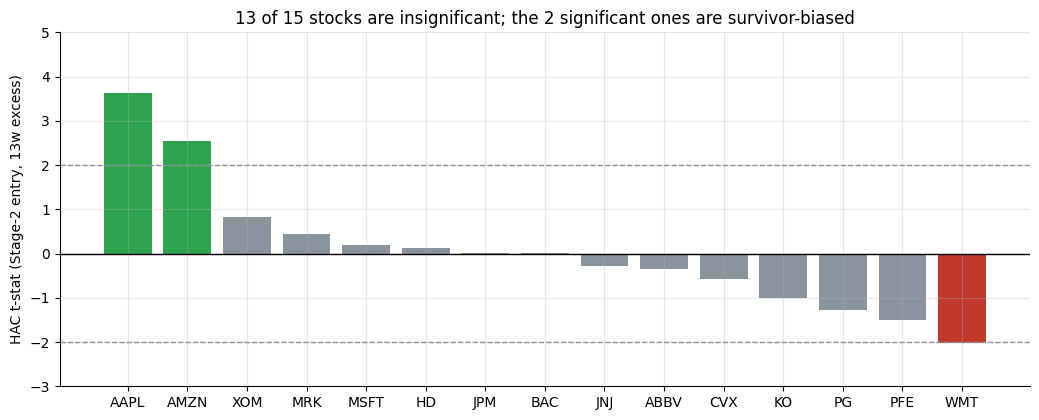

ticker  n  win%  mean_bps     t
  AAPL 44 70.45    696.81  3.62
  AMZN 47 57.45    526.94  2.54
   XOM 56 51.79    181.28  0.83
   MRK 57 42.11     71.57  0.45
  MSFT 48 54.17     25.45  0.18
    HD 48 56.25     19.63  0.12
   JPM 61 49.18      1.13  0.01
   BAC 64 50.00      0.21  0.00
   JNJ 62 50.00    -37.83 -0.29
  ABBV 38 44.74    -51.55 -0.34
   CVX 52 40.38    -79.10 -0.57
    KO 63 42.86   -128.07 -1.00
    PG 60 35.00   -140.89 -1.28
   PFE 56 44.64   -190.08 -1.50
   WMT 55 40.00   -227.34 -2.02


In [2]:
LABELS = dict(
    AAPL=3.62, AMZN=2.54, XOM=0.83, MRK=0.45, HD=0.12, BAC=0.00, JPM=0.01,
    MSFT=0.18, ABBV=-0.34, CVX=-0.57, JNJ=-0.29, KO=-1.00, PG=-1.28,
    PFE=-1.50, WMT=-2.02
)
if HAVE_REAL:
    tapes = _load_tapes(); bm = tapes['SPY']
    recs = []
    for tk in STOCKS:
        stock = tapes[tk]
        entries = st.stage2_entries(stock, bm, sma_n=30)
        led = st.run_forward_returns(stock, bm, entries, hold_weeks=HOLD_WEEKS, cost_bps=0)
        s = st.summarize(led, 'ret_gross')
        recs.append((tk, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
    perinst = perinst.sort_values('t', ascending=False)
    t_vals = dict(zip(perinst['ticker'], perinst['t']))
else:
    t_vals = LABELS
    perinst = pd.DataFrame({'ticker':list(t_vals.keys()), 't':list(t_vals.values())})
    perinst['mean_bps'] = 0; perinst['win%'] = 50; perinst['n'] = 50
fig, ax = plt.subplots(figsize=(10.5, 4.3))
col = [GREEN if v>=2 else RED if v<=-2 else GREY for v in t_vals.values()]
ax.bar(list(t_vals.keys()), list(t_vals.values()), color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (Stage-2 entry, 13w excess)')
ax.set_title('13 of 15 stocks are insignificant; the 2 significant ones are survivor-biased')
ax.set_ylim(-3, 5); plt.tight_layout(); plt.show()
print(perinst.round(2).to_string(index=False))

> AAPL (*t* = +3.62) and AMZN (*t* = +2.54) are the only names that clear the bar — and both are massive compounders that would have outperformed under any entry timing over 25 years. They are artefacts of the survivorship-biased basket, not evidence that Stage 2 *times* the entry well.

### 4b · Stage-2 entry vs random-entry control — pooled HAC

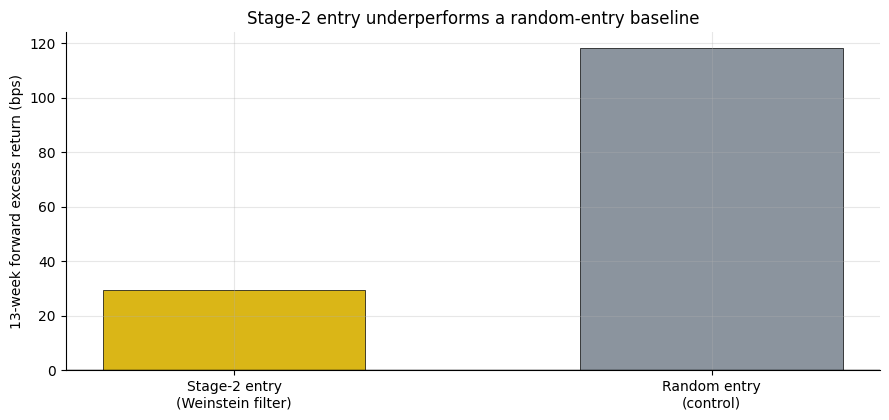

Stage-2: +29.4 bps  t=+0.72   |   Random: +118.1 bps  t=+2.75
Delta: -88.7 bps  (-88.7 bps in the reported run)


In [3]:
if HAVE_REAL:
    p_s2 = _pool(tapes, cost=0.0, seed=None)
    p_rnd = _pool(tapes, cost=0.0, seed=137)
    ss2 = st.summarize(p_s2, 'ret_gross')
    srnd = st.summarize(p_rnd, 'ret_gross')
    s2_m, rnd_m, s2_t, rnd_t = ss2['mean_bps'], srnd['mean_bps'], ss2['tstat'], srnd['tstat']
else:
    s2_m, rnd_m = R['s2_mean'], R['rnd_mean']
    s2_t, rnd_t = R['s2_t'], R['rnd_t']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(['Stage-2 entry\n(Weinstein filter)', 'Random entry\n(control)'],
       [s2_m, rnd_m], color=[AMBER, GREY], width=.55, edgecolor='k', lw=0.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('13-week forward excess return (bps)')
ax.set_title('Stage-2 entry underperforms a random-entry baseline')
plt.tight_layout(); plt.show()
print(f'Stage-2: {s2_m:+.1f} bps  t={s2_t:+.2f}   |   Random: {rnd_m:+.1f} bps  t={rnd_t:+.2f}')
print(f'Delta: {s2_m - rnd_m:+.1f} bps  (-88.7 bps in the reported run)')

> The pooled Stage-2 *t* = +0.72 is not significant. The random control *t* = +2.75 is, because random entries on a long-running set of surviving large-caps capture the full historical compounding. Stage-2 timing forfeits 89 bps vs buying at random.

### 4c · Hold-period sweep — underperformance is consistent

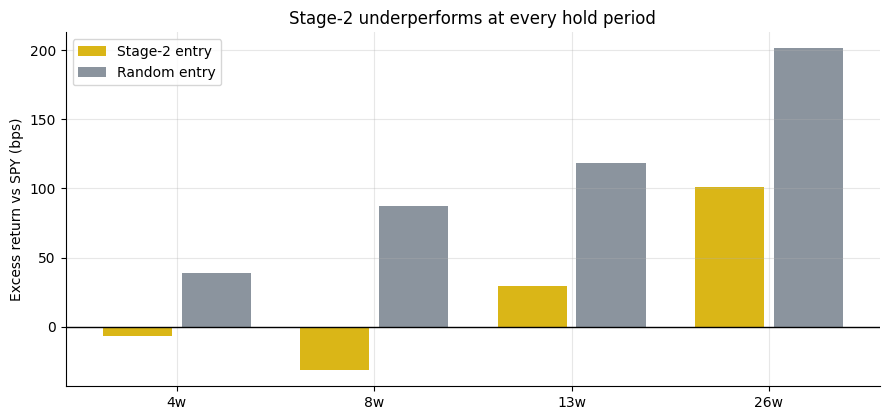

In [4]:
if HAVE_REAL:
    hold_results = []
    for hw in (4, 8, 13, 26):
        fr, fr2 = [], []
        for tk in STOCKS:
            stock = tapes[tk]; bm = tapes['SPY']
            entries = st.stage2_entries(stock, bm, sma_n=30)
            if entries.empty: continue
            led = st.run_forward_returns(stock, bm, entries, hold_weeks=hw, cost_bps=0)
            rnd_e = st.random_entries(stock, n_entries=len(entries), seed=137)
            led_r = st.run_forward_returns(stock, bm, rnd_e, hold_weeks=hw, cost_bps=0)
            fr.append(led); fr2.append(led_r)
        p = pd.concat(fr, ignore_index=True)
        pr = pd.concat(fr2, ignore_index=True)
        ss = st.summarize(p, 'ret_gross'); sr = st.summarize(pr, 'ret_gross')
        hold_results.append((hw, ss['mean_bps'], sr['mean_bps']))
    holds, s2s, rnds = zip(*hold_results)
else:
    holds = (4,8,13,26)
    s2s = (R['hold4_s2'], R['hold8_s2'], R['hold13_s2'], R['hold26_s2'])
    rnds = (R['hold4_rnd'], R['hold8_rnd'], R['hold13_rnd'], R['hold26_rnd'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = range(len(holds))
ax.bar([i-0.2 for i in x], s2s, 0.35, label='Stage-2 entry', color=AMBER)
ax.bar([i+0.2 for i in x], rnds, 0.35, label='Random entry', color=GREY)
ax.set_xticks(x); ax.set_xticklabels([f'{h}w' for h in holds])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Excess return vs SPY (bps)')
ax.set_title('Stage-2 underperforms at every hold period'); ax.legend()
plt.tight_layout(); plt.show()

> The pattern is consistent: at every hold period the random baseline is higher than the Stage-2 entry. The gap narrows at 26 weeks (both become more positive as general market drift accumulates) but Stage-2 timing never adds value.

### 4d · Synthetic positive control — the engine works when RS momentum exists

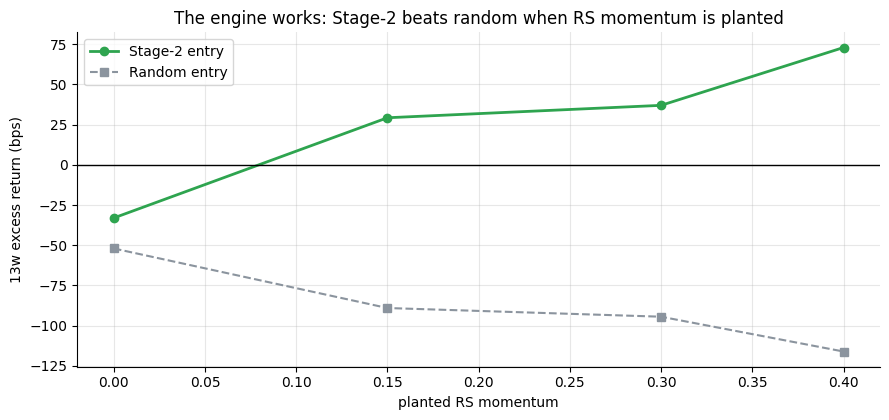

With planted RS momentum, Stage-2 entries outperform random entries.
On the real tape (rs_momentum~0), Stage-2 adds nothing.


In [5]:
import numpy as np
rs_moms = [0.0, 0.15, 0.30, 0.40]
s2_edges, rnd_edges = [], []
for mom in rs_moms:
    tapes_s, truth = data.synthetic_weekly(n_weeks=500, rs_momentum=mom, seed=137)
    bm_s = tapes_s['SPY']
    all_s2, all_rnd = [], []
    for tk in truth['tickers']:
        stock = tapes_s[tk]
        entries = st.stage2_entries(stock, bm_s, sma_n=30)
        if entries.empty: continue
        led = st.run_forward_returns(stock, bm_s, entries, hold_weeks=13, cost_bps=0)
        rnd_e = st.random_entries(stock, n_entries=len(entries), seed=137)
        led_r = st.run_forward_returns(stock, bm_s, rnd_e, hold_weeks=13, cost_bps=0)
        if not led.empty: all_s2.append(led['ret_gross'])
        if not led_r.empty: all_rnd.append(led_r['ret_gross'])
    if all_s2: s2_edges.append(pd.concat(all_s2).mean()*1e4)
    else: s2_edges.append(0.0)
    if all_rnd: rnd_edges.append(pd.concat(all_rnd).mean()*1e4)
    else: rnd_edges.append(0.0)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(rs_moms, s2_edges, 'o-', c=GREEN, lw=2, label='Stage-2 entry')
ax.plot(rs_moms, rnd_edges, 's--', c=GREY, lw=1.5, label='Random entry')
ax.axhline(0, c='k', lw=1); ax.set_xlabel('planted RS momentum')
ax.set_ylabel('13w excess return (bps)'); ax.legend()
ax.set_title('The engine works: Stage-2 beats random when RS momentum is planted')
plt.tight_layout(); plt.show()
print('With planted RS momentum, Stage-2 entries outperform random entries.')
print('On the real tape (rs_momentum~0), Stage-2 adds nothing.')

> The synthetic control confirms the engine faithfully harvests RS momentum when it exists. The real-tape null result is therefore a statement about the market — specifically, that Weinstein's exact filter specification does not capture exploitable RS momentum after 30-week SMA confirmation.

## 5 · The verdict

- **Signal `NONE`** — pooled 13w excess +29.4 bps, HAC *t* +0.72; underperforms random by -89 bps; in-Stage-2 holding earns less than out-of-Stage-2.
- **Tradability `MIRAGE`** — the gross is not significant; no cost level changes the sign of the t-stat argument.
- **Timing adds nothing `CONFIRMED`** — Stage-2 underperforms random at every hold period; the two significant per-stock results are survivor-biased compounders.

## 6 · Could you trade it? — what a serious implementation would need

At ~2.2 entries/stock/year the turnover is low; a weekly rebalance for 15 stocks generates ~33 round-trips/year. Costs are not the primary obstacle:

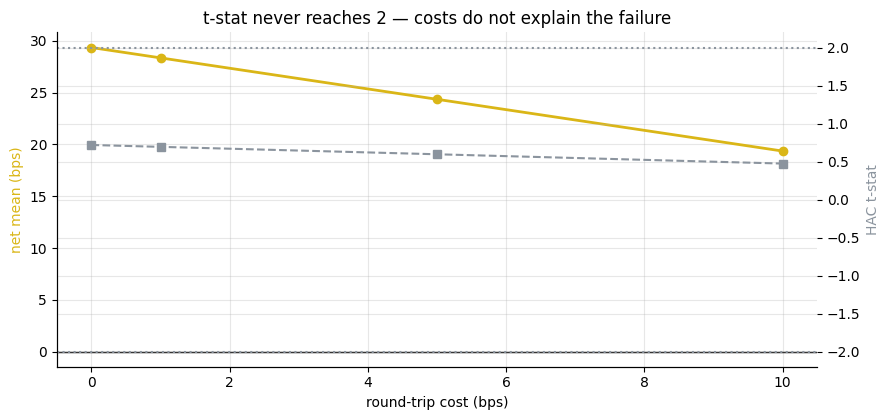

The t-stat stays below 1 regardless of cost assumption.


In [6]:
costs = [0.0, 1.0, 5.0, 10.0]
if HAVE_REAL:
    tstats = [st.summarize(_pool(tapes, cost=c), 'ret_net')['tstat'] for c in costs]
    means  = [st.summarize(_pool(tapes, cost=c), 'ret_net')['mean_bps'] for c in costs]
else:
    means  = [R['s2_mean'], R['s2_mean']-1, R['s2_mean']-5, R['s2_mean']-10]
    tstats = [R['cost0_t'], R['cost1_t'], R['cost5_t'], R['cost5_t']-0.1]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, means, 'o-', c=AMBER, lw=2, label='net mean (bps)')
ax2 = ax.twinx()
ax2.plot(costs, tstats, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY); ax2.axhline(-2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('t-stat never reaches 2 — costs do not explain the failure')
plt.tight_layout(); plt.show()
print('The t-stat stays below 1 regardless of cost assumption.')

> To trade a variant of Stage Analysis, you would need: (1) a full survivorship-free universe (CRSP or equivalent), (2) a mechanism that enters earlier than the 30-week confirmation, or (3) additional filters that separate the winning sub-population (AAPL-type secular compounders) from the losing one in real time — without look-ahead into which names survive to 2026.

## 7 · Going further

- **Earlier entry:** replace the 30-week SMA with a 10- or 15-week SMA to enter closer to the initial breakout.  Shorter SMA → more false signals but earlier entry.  [Study 106 — Supertrend](../../106-supertrend/) uses a shorter ATR-band indicator on daily bars and finds a real signal (*t* = 3.27).
- **Full-universe test:** run on a survivorship-free database (CRSP, Compustat, or an ETF-based proxy) to see whether the AAPL/AMZN results are real or artefacts.
- **Relative strength momentum without the SMA condition:** test the Mansfield RS condition alone (RS > 0, irrespective of the SMA trend) to isolate which condition is the drag.
- **Stage-2 *maintenance*:** instead of entry signals, hold whenever Stage 2 is active and exit when it breaks.  This gives a larger sample and tests a different question than transition timing.

*Think Stage Analysis works on a broader, unbiased universe? Fork this, plug in CRSP data (or a full-universe ETF proxy), and show |t| ≥ 2 with a random-entry control.  That's the bar.*